In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import geopandas as gp
import numpy as np
from rasterio.features import rasterize
import rioxarray
from rasterio.features import shapes
from rioxarray import set_options
import numpy as np
import contextily as cx
from shapely.geometry import box, mapping, shape, Point
from rasterio.features import shapes as raster_to_shapes
import matplotlib.pyplot as plt
from shapely.geometry import Point
import pystac_client
import planetary_computer as pc
import pandas as pd
import geopandas as gpd
import os
from utils import (
    search_wide_area,
    choose_aoi,
    find_candidates,
    pick_scenes,
    load_scene,
    mask_and_scale,
    valid_observation_count,
    ndvi,
    ndmi,
    evi,
    bsi,
    false_color,
    period_median,
)

# Validation against PRODES

How far can the alerts be trusted? This notebook compares them with PRODES, the annual deforestation map produced by INPE for the Brazilian Amazon. It reads the results of the detection notebook from `outputs/` and does not download any satellite data.

PRODES is a reference with its own rules. It maps only clear-cut of primary forest, in patches of at least 6.25 hectares, and once an area is recorded as deforested it is never mapped again. The alerts measure something broader: any strong drop in vegetation between the two periods. Part of the disagreement between the two therefore comes from their definitions.

## 1. Load PRODES over the AOI

The full PRODES file covers the whole Legal Amazon. Reading it with a bounding box returns only the polygons that touch the AOI, which are then saved to a small file so the large download is needed only once.

In [2]:
path= "data/prodes_amazonia_legal_v20260717.gpkg"
gpd.list_layers(path)

,name,geometry_type
0,accumulated_deforestation_2007,Unknown
1,yearly_deforestation,Unknown
2,no_forest,Unknown
3,hydrography,Unknown
4,residual,Unknown


In [3]:
bbox = (-63.4613, -9.5921, -63.3613, -9.4921)
prodes= gpd.read_file(path, layer="yearly_deforestation", bbox=bbox)
prodes

,state,path_row,main_class,class_name,sub_class,def_cloud,julian_day,image_date,year,area_km,scene_id,source,satellite,sensor,uuid,geometry
0,RO,23267,DESMATAMENTO,d2019,d2019,0.0,208,2019-07-27,2019,0.062986,35,NaN,Landsat,OLI,406e87f4-414e-4f1a-b70f-7a7e7937fa8e,"MULTIPOLYGON (((-63.43439 -9.5604, -63.43393 -..."
1,RO,23267,DESMATAMENTO,d2013,d2013,0.0,207,2013-07-26,2013,0.271505,2037,NaN,Landsat,OLI,1feed247-4b3b-4d37-9dbb-af5aeb4f77e9,"MULTIPOLYGON (((-63.46721 -9.56211, -63.46721 ..."
2,RO,23267,DESMATAMENTO,d2013,d2013,0.0,207,2013-07-26,2013,0.151129,2037,NaN,Landsat,OLI,bd2229de-dbab-49a2-bcf8-57d54fbd34cb,"MULTIPOLYGON (((-63.42848 -9.55082, -63.42821 ..."
3,RO,23267,DESMATAMENTO,d2015,d2015,0.0,213,2015-08-01,2015,0.092835,2539,NaN,Landsat,OLI,1df26032-64e1-4c54-a607-53e02f8b9479,"MULTIPOLYGON (((-63.43351 -9.55986, -63.43351 ..."
4,RO,23267,DESMATAMENTO,d2016,d2016,0.0,40,2016-02-09,2016,0.024964,100123,NaN,Landsat,OLI,d996e976-bd62-4070-8315-76e1c8439286,"MULTIPOLYGON (((-63.43143 -9.54651, -63.43063 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,RO,23267,DESMATAMENTO,d2016,d2016,0.0,245,2015-09-02,2016,0.037302,100004,NaN,Landsat,OLI,3e3bc1bd-2b27-482a-9a49-080cf0569510,"MULTIPOLYGON (((-63.39109 -9.57099, -63.39055 ..."
102,RO,23267,DESMATAMENTO,d2021,d2021,NaN,197,2021-07-16,2021,0.124637,1031,NaN,Landsat,OLI,20537fef-b20b-43ce-a3d2-6c2c55016fca,"MULTIPOLYGON (((-63.37306 -9.5834, -63.3729 -9..."
103,RO,23267,DESMATAMENTO,d2016,d2016,0.0,245,2015-09-02,2016,0.063431,100004,NaN,Landsat,OLI,38ecf502-a632-415a-82cc-73f60806e61f,"MULTIPOLYGON (((-63.36635 -9.58157, -63.36635 ..."
104,RO,23267,DESMATAMENTO,d2017,d2017,0.0,202,2017-07-21,2017,0.084305,100580,NaN,Landsat,OLI,f8e26bfe-230f-4037-9608-0a9e6bbf10aa,"MULTIPOLYGON (((-63.3742 -9.56669, -63.3742 -9..."


## 2. A first look at the data

PRODES is distributed in SIRGAS 2000 (EPSG:4674), the official geodetic system of Brazil. Like EPSG:4326 it is in degrees and the two differ by less than a metre here, but geopandas needs both layers in the same system before combining them.

The count of polygons per year shows when the AOI was cleared: 76 polygons date from 2008 to 2018 and only 30 from 2019 to 2023. Most of the deforestation in this area happened before the baseline period.

In [4]:
print(prodes.crs)
print(prodes.columns.tolist())
print(len(prodes), "polygons")

EPSG:4674
['state', 'path_row', 'main_class', 'class_name', 'sub_class', 'def_cloud', 'julian_day', 'image_date', 'year', 'area_km', 'scene_id', 'source', 'satellite', 'sensor', 'uuid', 'geometry']
106 polygons


In [5]:
prodes["year"].value_counts().sort_index()

year
2008     4
2009     4
2010     3
2011     4
2012     2
2013     9
2014     4
2015     8
2016    19
2017    12
2018     7
2019     7
2020     4
2021     9
2022     6
2023     4
Name: count, dtype: int64

## 3. Which years to compare

A PRODES year runs from August to July, so PRODES 2019 covers August 2018 to July 2019. The baseline scenes are from July to September 2018 and the recent ones from June to September 2023.

PRODES 2018 is left out: those areas were already cleared in the baseline scenes, so they show no change between the two periods. The years 2019 to 2023 are kept, as they fall between the two windows.

In [6]:
prodes_change = prodes[(prodes["year"]>=2019) & (prodes["year"]<=2023)]
print(len(prodes_change), "polygons") 

30 polygons


## 4. Clip to the AOI

The bounding box filter keeps whole polygons, including the parts that extend beyond the AOI. Clipping removes those parts, so that areas are measured over the same ground as the alerts.

In [7]:
aoi = gpd.GeoDataFrame(geometry=[box(*bbox)], crs="EPSG:4326").to_crs(prodes.crs)
prodes_change = gpd.clip(prodes_change, aoi)

## 5. Load the alerts

The alerts produced by the detection notebook: areas where NDVI dropped by more than the threshold, confirmed by a rise in bare soil, larger than half a hectare and not on water.

In [8]:
alerts = gpd.read_file("outputs/deforestation_alerts.geojson")
print(len(alerts), "alerts")

129 alerts


In [9]:
prodes_change.to_file("data/prodes_aoi.gpkg", layer="deforestation_2019_2023", driver="GPKG")

## 6. A visual comparison

PRODES polygons in yellow and alerts in red, over a satellite basemap. The basemap is a mosaic of unknown dates and is there only for orientation: it shows neither 2018 nor 2023.

Before computing any metric, three things are worth reading off the map: how many PRODES polygons contain an alert, how many alerts have no PRODES polygon nearby, and what kind of land those isolated alerts sit on.

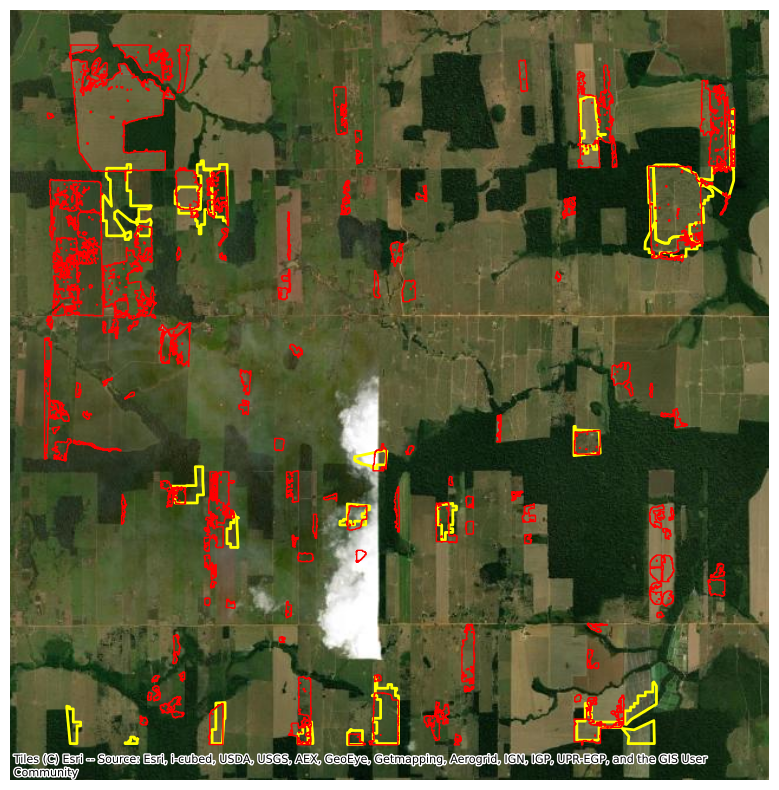

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
prodes_change.to_crs(epsg=3857).plot(ax=ax, facecolor="none", edgecolor="yellow", linewidth=2)
alerts.to_crs(epsg=3857).plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)
ax.set_axis_off()
plt.show()

## 7. A common grid

To compare the two layers pixel by pixel they must sit on the same grid. The NDVI change raster provides it: its shape, position and projection define the pixels on which both PRODES and the alerts are drawn. Its values are not used here.

Both vector layers are first reprojected to the projection of the raster (UTM), so that their coordinates are in the same metres as the grid.

In [11]:
file_ndvi= 'ndvi_change.tif'

In [12]:
ndvi_raster= rioxarray.open_rasterio(file_ndvi).squeeze("band", drop=True)

In [13]:
print(ndvi_raster.rio.crs,ndvi_raster.shape)

EPSG:32720 (1108, 1100)


In [14]:
prodes_utm = prodes_change.to_crs(ndvi_raster.rio.crs)
alerts_utm = alerts.to_crs(ndvi_raster.rio.crs)

## 8. From polygons to masks

Each layer is rasterized: every pixel of the grid gets 1 if it falls inside a polygon and 0 otherwise. This is the reverse of the step that turned the change map into polygons in the detection notebook.

As a check, the area counted from the mask (pixels × 100 m²) should match the area measured on the polygons. A large gap between the two would mean the layers and the grid are not in the same reference system.

In [15]:
prodes_mask = rasterize(prodes_utm.geometry, out_shape=ndvi_raster.shape,
                        transform=ndvi_raster.rio.transform(), fill=0, dtype="uint8")
alerts_mask = rasterize(alerts_utm.geometry, out_shape=ndvi_raster.shape,
                        transform=ndvi_raster.rio.transform(), fill=0, dtype="uint8")

In [16]:
print("PRODES pixels:", prodes_mask.sum())
print("alert pixels:", alerts_mask.sum())


PRODES pixels: 40907
alert pixels: 105031


## 9. Agreement, pixel by pixel

Every pixel falls into one of four cases: flagged by both, by the alerts only, by PRODES only, or by neither. From these counts:

- **Precision**: of everything the alerts flag, how much PRODES also maps.
- **Recall**: of everything PRODES maps, how much the alerts find.
- **F1**: a single score that balances the two.

Accuracy is reported too, but it is not a useful measure here. Most of the AOI did not change according to either source, and those pixels count as correct, so a method that never flagged anything would still score very high.

The alerts cover a much larger area than PRODES, which puts a ceiling on precision before any comparison is made: the pixels in agreement can never be more than the PRODES pixels.

In [17]:
prodes_bool = prodes_mask.astype(bool)
alerts_bool = alerts_mask.astype(bool)

true_pos = (alerts_bool & prodes_bool).sum()
false_pos = (alerts_bool & ~prodes_bool).sum()
false_neg = (~alerts_bool & prodes_bool).sum()
true_neg = (~alerts_bool & ~prodes_bool).sum()

precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1 = 2 * precision * recall / (precision + recall)
accuracy = (true_pos + true_neg) / prodes_bool.size

print(f"true positives:  {true_pos / 100:8.1f} ha")
print(f"false positives: {false_pos / 100:8.1f} ha")
print(f"false negatives: {false_neg / 100:8.1f} ha")
print()
print(f"precision: {precision:.1%}")
print(f"recall:    {recall:.1%}")
print(f"F1:        {f1:.1%}")
print(f"accuracy:  {accuracy:.1%}")

true positives:     239.3 ha
false positives:    811.0 ha
false negatives:    169.7 ha

precision: 22.8%
recall:    58.5%
F1:        32.8%
accuracy:  92.0%


## 10. Where the two agree and where they do not

The same four cases, drawn on the map. Green is agreement, red is flagged by the alerts only, blue is mapped by PRODES only.

The shape of the disagreement matters more than its amount. A thin blue rim around a green patch means the two sources outline the same clearing slightly differently, which is expected when one works at 30 m and the other at 10 m. A solid blue patch is a clearing the alerts missed entirely. Red areas far from any green are either false alarms or real changes that fall outside what PRODES records, and the next section tries to tell the two apart.

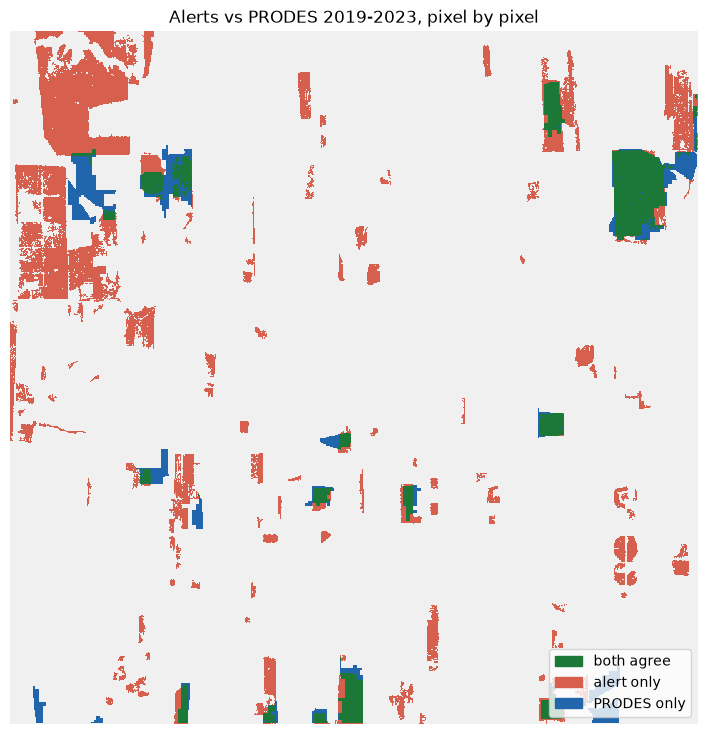

In [18]:
classes = np.zeros(prodes_bool.shape, dtype="uint8")
classes[alerts_bool & prodes_bool] = 1     # agreement
classes[alerts_bool & ~prodes_bool] = 2    # alert only
classes[~alerts_bool & prodes_bool] = 3    # PRODES only

colors = ["#f0f0f0", "#1b7837", "#d6604d", "#2166ac"]
labels = ["neither", "both agree", "alert only", "PRODES only"]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(classes, cmap=ListedColormap(colors), interpolation="nearest")
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(colors[1:], labels[1:])],
          loc="lower right")
ax.set_title("Alerts vs PRODES 2019-2023, pixel by pixel")
ax.set_axis_off()
plt.savefig("outputs/prodes_confusion_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Land that PRODES no longer watches

PRODES records an area once. After that, nothing that happens there is mapped again. To know where PRODES can still report new deforestation, all the land recorded before the study period is needed: the accumulated deforestation up to 2007 and the yearly polygons from 2008 to 2018.

Two other layers, non-forest vegetation and hydrography, would be excluded for the same reason, but both are empty over this AOI. PRODES maps only large water bodies, and the small ponds found in the detection notebook are below its scale.

In [19]:
accumulated = gpd.read_file(path, layer="accumulated_deforestation_2007", bbox=bbox)
no_forest = gpd.read_file(path, layer="no_forest", bbox=bbox)
hydrography = gpd.read_file(path, layer="hydrography", bbox=bbox)

for name, layer in [("accumulated to 2007", accumulated),
                    ("no forest", no_forest), ("hydrography", hydrography)]:
    print(f"{name}: {len(layer)} polygons")

accumulated to 2007: 5 polygons
no forest: 0 polygons
hydrography: 0 polygons


## 12. A mask of land already cleared by 2018

Both layers are drawn on the common grid and merged: a pixel belongs to the mask if it was cleared at any time before 2019. When it happened does not matter here, only that PRODES had already recorded it.

The two layers should never overlap, since the same area is not recorded twice. An overlap of zero confirms this and shows that the layers line up on the grid.

In [20]:
accumulated_utm = accumulated.to_crs(ndvi_raster.rio.crs)
accumulated_mask = rasterize(accumulated_utm.geometry, out_shape=ndvi_raster.shape,
                             transform=ndvi_raster.rio.transform(), fill=0, dtype="uint8")
print(accumulated_mask.sum(), "pixels")

848768 pixels


In [21]:
earlier = prodes[(prodes["year"] >= 2008) & (prodes["year"] <= 2018)]
print(len(earlier), "polygons")

earlier_utm = earlier.to_crs(ndvi_raster.rio.crs)
earlier_mask = rasterize(earlier_utm.geometry, out_shape=ndvi_raster.shape,
                         transform=ndvi_raster.rio.transform(), fill=0, dtype="uint8")
print(earlier_mask.sum(), "pixels")

76 polygons
95483 pixels


In [22]:
accumulated_bool = accumulated_mask.astype(bool)
earlier_bool = earlier_mask.astype(bool)
not_forest_2018 = accumulated_bool | earlier_bool

n_acc, n_rec, n_union = accumulated_bool.sum(), earlier_bool.sum(), not_forest_2018.sum()
print(n_acc, n_rec, n_union)
print("overlap:", n_acc + n_rec - n_union)
print(f"not forest in 2018: {not_forest_2018.mean():.1%} of the AOI")

848768 95483 944251
overlap: 0
not forest in 2018: 77.5% of the AOI


## 13. Where do the false positives fall?

The alerts with no matching PRODES polygon are split in two. Those inside the mask sit on land cleared before 2019, where PRODES cannot confirm or reject anything. Those outside sit on what PRODES considers standing forest, and are the real disagreements between the two sources.

As a check, no PRODES polygon of 2019 to 2023 should fall inside the mask.

In [23]:
fp_mask = alerts_bool & ~prodes_bool
fp_cleared = fp_mask & not_forest_2018       # on land already cleared
fp_forest = fp_mask & ~not_forest_2018       # on standing forest

print(f"false positives:            {fp_mask.sum() / 100:8.1f} ha")
print(f"  on land already cleared:  {fp_cleared.sum() / 100:8.1f} ha "
      f"({fp_cleared.sum() / fp_mask.sum():.1%})")
print(f"  on standing forest:       {fp_forest.sum() / 100:8.1f} ha "
      f"({fp_forest.sum() / fp_mask.sum():.1%})")
print("PRODES pixels inside the mask:", (prodes_bool & not_forest_2018).sum())

false positives:               811.0 ha
  on land already cleared:     753.9 ha (93.0%)
  on standing forest:           57.0 ha (7.0%)
PRODES pixels inside the mask: 0


## 14. Precision on equal terms

The first precision compared alerts drawn over the whole AOI with a reference that can only report on the part still forested in 2018. Restricting the alerts to that same part compares the two sources over the same ground.

Recall is unchanged, since the mask removes alerts and leaves the PRODES polygons untouched.

In [24]:
alerts_forest = alerts_bool & ~not_forest_2018
tp_forest = (alerts_forest & prodes_bool).sum()

precision_forest = tp_forest / alerts_forest.sum()

print(f"precision, whole AOI:   {precision:.1%}")
print(f"precision, forest only: {precision_forest:.1%}")
print(f"recall:                 {recall:.1%}")

precision, whole AOI:   22.8%
precision, forest only: 80.8%
recall:                 58.5%


## 15. The same map, with the cleared land set apart

The alert-only pixels are now shown in two colours: orange where the land had already been cleared, red where PRODES sees standing forest. The red that remains is what still needs an explanation.

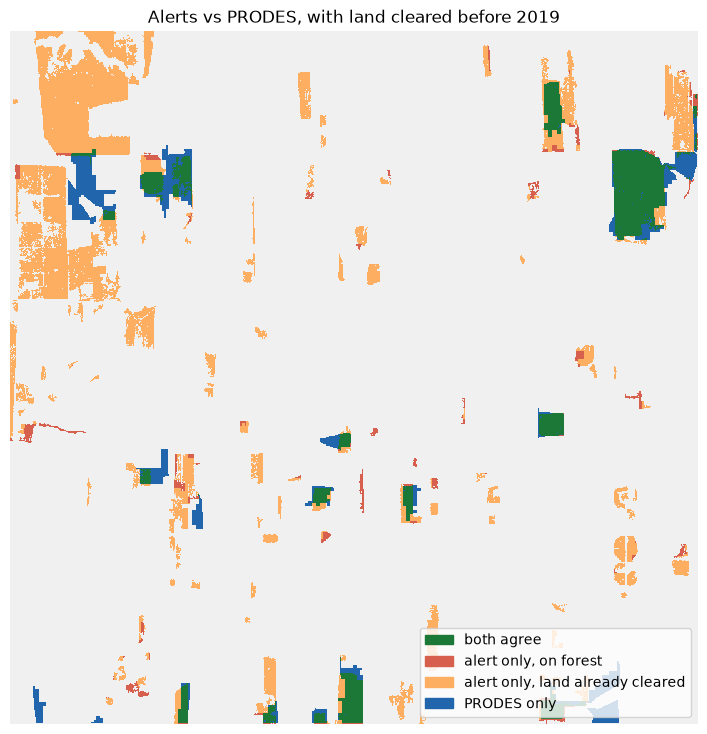

In [25]:
classes = np.zeros(alerts_bool.shape, dtype="uint8")
classes[alerts_bool & prodes_bool] = 1     # both agree
classes[fp_forest] = 2                     # alert only, on forest
classes[fp_cleared] = 3                    # alert only, on land already cleared
classes[~alerts_bool & prodes_bool] = 4    # PRODES only

colors = ["#f0f0f0", "#1b7837", "#d6604d", "#fdae61", "#2166ac"]
labels = ["neither", "both agree", "alert only, on forest",
          "alert only, land already cleared", "PRODES only"]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(classes, cmap=ListedColormap(colors), interpolation="nearest")
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(colors[1:], labels[1:])],
          loc="lower right")
ax.set_title("Alerts vs PRODES, with land cleared before 2019")
ax.set_axis_off()
plt.savefig("outputs/prodes_confusion_map_4classes.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
alerts_union = alerts_utm[["geometry"]].dissolve()

pieces = gpd.overlay(prodes_utm[["prodes_id", "geometry"]], alerts_union, how="intersection")
pieces["overlap_m2"] = pieces.geometry.area

covered = pieces.groupby("prodes_id")["overlap_m2"].sum()
prodes_utm["covered_m2"] = prodes_utm["prodes_id"].map(covered).fillna(0)
prodes_utm["coverage"] = prodes_utm["covered_m2"] / prodes_utm["area_m2"]
prodes_utm["area_ha"] = prodes_utm["area_m2"] / 10_000

prodes_utm["coverage"].describe()

count    30.000000
mean      0.481586
std       0.360262
min       0.000000
25%       0.081928
50%       0.544358
75%       0.834895
max       0.986389
Name: coverage, dtype: float64

In [35]:
FOUND_THRESHOLD = 0.5

prodes_utm["detection"] = np.select(
    [prodes_utm["coverage"] >= FOUND_THRESHOLD, prodes_utm["coverage"] > 0],
    ["found", "partial"],
    default="missed",
)
prodes_utm["detection"].value_counts()

detection
found      16
partial     9
missed      5
Name: count, dtype: int64

year
2019    0.66
2020    0.26
2021    0.47
2022    0.29
2023    0.70
Name: coverage, dtype: float64

detection  found  missed  partial
year                             
2019           5       0        2
2020           1       2        1
2021           5       1        3
2022           2       2        2
2023           3       0        1


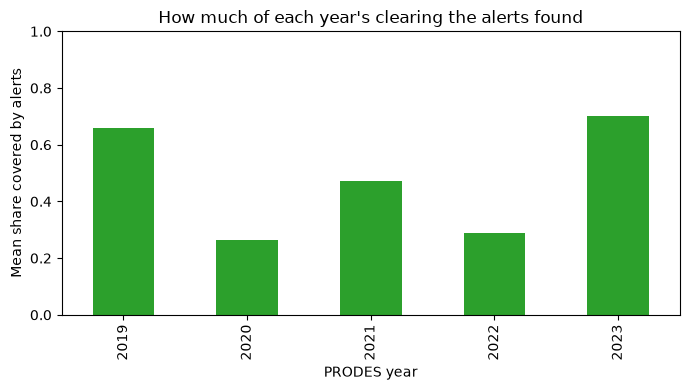

In [36]:
print(prodes_utm.groupby("year")["coverage"].mean().round(2))
print()
print(pd.crosstab(prodes_utm["year"], prodes_utm["detection"]))

ax = prodes_utm.groupby("year")["coverage"].mean().plot.bar(figsize=(7, 4), color="tab:green")
ax.set_ylabel("Mean share covered by alerts")
ax.set_xlabel("PRODES year")
ax.set_ylim(0, 1)
ax.set_title("How much of each year's clearing the alerts found")
plt.tight_layout()
plt.savefig("outputs/detection_by_year.png", dpi=150)
plt.show()

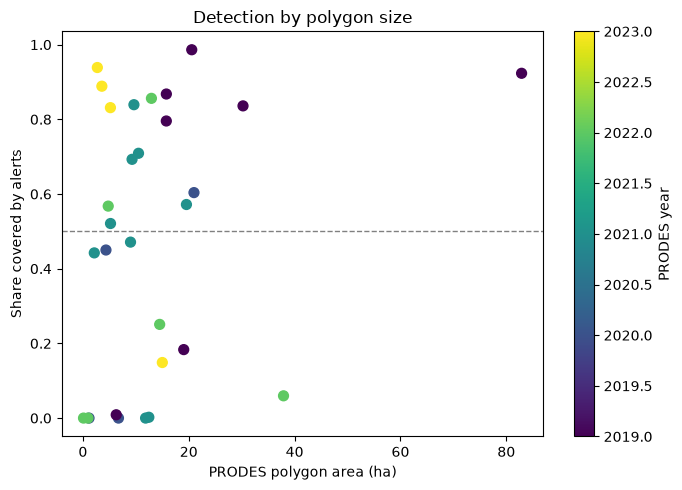

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))
points = ax.scatter(prodes_utm["area_ha"], prodes_utm["coverage"],
                    c=prodes_utm["year"], cmap="viridis", s=50)
fig.colorbar(points, ax=ax, label="PRODES year")
ax.axhline(FOUND_THRESHOLD, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("PRODES polygon area (ha)")
ax.set_ylabel("Share covered by alerts")
ax.set_title("Detection by polygon size")
plt.tight_layout()
plt.savefig("outputs/detection_by_size.png", dpi=150)
plt.show()

In [38]:
def mean_ndvi_change(geometry):
    clipped = ndvi_raster.rio.clip([geometry], prodes_utm.crs)
    return float(clipped.mean(skipna=True))

prodes_utm["mean_ndvi_change"] = prodes_utm.geometry.apply(mean_ndvi_change)

prodes_utm.groupby("detection")["mean_ndvi_change"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
detection,,,,,,,,
found,16.0,-0.329,0.081,-0.471,-0.386,-0.327,-0.281,-0.166
missed,5.0,-0.061,0.084,-0.176,-0.113,-0.029,-0.029,0.040
partial,9.0,-0.138,0.061,-0.251,-0.169,-0.114,-0.101,-0.047


In [39]:
not_found = prodes_utm[prodes_utm["detection"] != "found"]
not_found[["year", "area_ha", "coverage", "mean_ndvi_change", "detection"]] \
    .sort_values("coverage").round(3)

,year,area_ha,coverage,mean_ndvi_change,detection
12,2020,1.153,0.000,0.040,missed
9,2020,6.715,0.000,-0.029,missed
97,2021,11.841,0.000,-0.029,missed
69,2022,0.946,0.000,-0.176,missed
72,2022,0.114,0.000,-0.113,missed
102,2021,12.454,0.002,-0.047,partial
0,2019,6.294,0.009,-0.101,partial
89,2022,37.904,0.060,-0.093,partial
54,2023,15.003,0.149,-0.169,partial
76,2019,19.050,0.183,-0.111,partial


In [40]:
residual = gpd.read_file(path, layer="residual", bbox=bbox)
print(len(residual), "residual polygons over the AOI")
if len(residual) > 0:
    print(residual["year"].value_counts().sort_index())

10 residual polygons over the AOI
year
2011    1
2015    2
2016    5
2021    1
2024    1
Name: count, dtype: int64
